In [1]:
# Installing beautiful soup
!pip install beautifulsoup4
!pip install lxml

In [2]:
from bs4 import BeautifulSoup
import requests
url = BeautifulSoup("https://www.sharesansar.com/live-trading", 'html.parser')
soup = requests.get(url)
print(soup)

/var/folders/05/v1yqhtr106q9gz2bdv34d4jc0000gn/T/ipykernel_13463/100107872.py:3: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  url = BeautifulSoup("https://www.sharesansar.com/live-trading", 'html.parser')


<Response [200]>


In [3]:
soup.text

'<!DOCTYPE html>\n<html lang="en">\n\n<head>\n    <meta charset="utf-8">\n<meta name="viewport"\n    content="width=device-width, user-scalable=no, initial-scale = 1.0, minimum-scale=1.0, maximum-scale = 1.0">\n<meta name="keywords"\n    content=" sharesansar, sharesansar.com, share market, best site, nepali bazar, news, nepal, economics, politics, entertainment, business, politics, businessman, online news, real state, tax, banking, corporate, telecom,  nepse, ipo, agm, bond, Oil, Gold, profit, shareholder, NEPSE, pravhu, ILFC, Stock, exchange, citizen, nepal., loan, loss, provision,  arun, valley, kabeli,  Economy, Growth, Rate, Eid, Public, Holiday,  Mastercard, Standard, Chartered, Credit, Card, Visa, Warren, Buffett, Value, Investing,Nepal Stock Exchange (NEPSE) Live Trading Data, Floorsheet, Live Indices, Top Gainers, Top Losers, nepse, shareapp, limted, iporesult, bank , share, bank, company, promoter, bittya santha" />\n\n<title>Live Trading - || ShareSansar ||</title>\n<!--[if

In [4]:
#Convert to xml file
codes = BeautifulSoup(soup.text, 'lxml')

In [5]:
#Fetcing only table code
table_content = codes.table

In [6]:
#Finding all tr tags from the table
tags = table_content.find_all('tr')
tags

[<tr>
 <th width="10px">S.No</th>
 <th>Symbol</th>
 <th class="text-center">LTP</th>
 <th class="text-center">Point Change</th>
 <th class="text-center">% Change</th>
 <th class="text-center">Open</th>
 <th class="text-center">High</th>
 <th class="text-center">Low</th>
 <th class="text-center">Volume</th>
 <th class="text-center">Prev. Close</th>
 </tr>,
 <tr>
 <td class="danger-index">
                                         1</td>
 <td class="danger-index">
 <a href="https://www.sharesansar.com/company/aclbsl" title="ACLBSL">ACLBSL</a>
 </td>
 <td class="text-center danger-index">
                                         1,040.00</td>
 <td class="text-center danger-index">
                                         -13.00</td>
 <td class="text-center danger-index">
                                         -1.23</td>
 <td class="text-center danger-index">
                                         1,040.00</td>
 <td class="text-center danger-index">
                                     

In [7]:
#Finding all td tags in tags
for i in tags:
    print(i.find_all('td'))

[]
[<td class="danger-index">
                                        1</td>, <td class="danger-index">
<a href="https://www.sharesansar.com/company/aclbsl" title="ACLBSL">ACLBSL</a>
</td>, <td class="text-center danger-index">
                                        1,040.00</td>, <td class="text-center danger-index">
                                        -13.00</td>, <td class="text-center danger-index">
                                        -1.23</td>, <td class="text-center danger-index">
                                        1,040.00</td>, <td class="text-center danger-index">
                                        1,043.00</td>, <td class="text-center danger-index">
                                        1,025.00</td>, <td class="text-center danger-index">
                                        2,970.00</td>, <td class="text-center danger-index">
                                        1,053.00</td>]
[<td class="success-index">
                                        2</

In [8]:
data = []
for i in tags:
    data.append(i.text)
print(data)

['\nS.No\nSymbol\nLTP\nPoint Change\n% Change\nOpen\nHigh\nLow\nVolume\nPrev. Close\n', '\n\n                                        1\n\nACLBSL\n\n\n                                        1,040.00\n\n                                        -13.00\n\n                                        -1.23\n\n                                        1,040.00\n\n                                        1,043.00\n\n                                        1,025.00\n\n                                        2,970.00\n\n                                        1,053.00\n', '\n\n                                        2\n\nADBL\n\n\n                                        333.10\n\n                                        3.10\n\n                                        0.94\n\n                                        330.00\n\n                                        334.00\n\n                                        321.50\n\n                                        85,296.00\n\n                             

In [9]:
#Excluding header file
data1 = data[1:]
data1

['\n\n                                        1\n\nACLBSL\n\n\n                                        1,040.00\n\n                                        -13.00\n\n                                        -1.23\n\n                                        1,040.00\n\n                                        1,043.00\n\n                                        1,025.00\n\n                                        2,970.00\n\n                                        1,053.00\n',
 '\n\n                                        2\n\nADBL\n\n\n                                        333.10\n\n                                        3.10\n\n                                        0.94\n\n                                        330.00\n\n                                        334.00\n\n                                        321.50\n\n                                        85,296.00\n\n                                        330.00\n',
 '\n\n                                        3\n\nAHL\n\n\n    

In [10]:
#
data1[0]

'\n\n                                        1\n\nACLBSL\n\n\n                                        1,040.00\n\n                                        -13.00\n\n                                        -1.23\n\n                                        1,040.00\n\n                                        1,043.00\n\n                                        1,025.00\n\n                                        2,970.00\n\n                                        1,053.00\n'

In [11]:
data1 = data[1:]
data1

['\n\n                                        1\n\nACLBSL\n\n\n                                        1,040.00\n\n                                        -13.00\n\n                                        -1.23\n\n                                        1,040.00\n\n                                        1,043.00\n\n                                        1,025.00\n\n                                        2,970.00\n\n                                        1,053.00\n',
 '\n\n                                        2\n\nADBL\n\n\n                                        333.10\n\n                                        3.10\n\n                                        0.94\n\n                                        330.00\n\n                                        334.00\n\n                                        321.50\n\n                                        85,296.00\n\n                                        330.00\n',
 '\n\n                                        3\n\nAHL\n\n\n    

In [12]:
data2 = data1[1].split("\n\n                                       ")
data2

['',
 ' 2\n\nADBL\n',
 ' 333.10',
 ' 3.10',
 ' 0.94',
 ' 330.00',
 ' 334.00',
 ' 321.50',
 ' 85,296.00',
 ' 330.00\n']

In [13]:
data3 = []
for i in data1:
    data3.append(i.replace("\n", "").split("                                       ")[1:])

In [14]:
print(data3)

[[' 1ACLBSL', ' 1,040.00', ' -13.00', ' -1.23', ' 1,040.00', ' 1,043.00', ' 1,025.00', ' 2,970.00', ' 1,053.00'], [' 2ADBL', ' 333.10', ' 3.10', ' 0.94', ' 330.00', ' 334.00', ' 321.50', ' 85,296.00', ' 330.00'], [' 3AHL', ' 521.00', ' -1.00', ' -0.19', ' 522.00', ' 525.90', ' 512.00', ' 12,223.00', ' 522.00'], [' 4AHPC', ' 314.00', ' 4.00', ' 1.29', ' 316.20', ' 316.20', ' 307.00', ' 389,922.00', ' 310.00'], [' 5AKJCL', ' 415.00', ' 12.90', ' 3.21', ' 395.00', ' 415.00', ' 395.00', ' 808,865.00', ' 402.10'], [' 6AKPL', ' 304.90', ' 2.90', ' 0.96', ' 296.00', ' 305.00', ' 296.00', ' 400,064.00', ' 302.00'], [' 7ALBSL', ' 1,293.90', ' 7.90', ' 0.61', ' 1,261.00', ' 1,300.00', ' 1,240.00', ' 22,614.00', ' 1,286.00'], [' 8ALICL', ' 488.00', ' -1.00', ' -0.20', ' 484.00', ' 490.00', ' 479.00', ' 48,491.00', ' 489.00'], [' 9ANLB', ' 6,647.00', ' 185.70', ' 2.87', ' 6,400.00', ' 6,649.00', ' 6,400.00', ' 4,414.00', ' 6,461.30'], [' 10API', ' 364.20', ' 5.20', ' 1.45', ' 359.00', ' 365.90', '

In [15]:
for i in data3:
    i[1] = float(i[1].replace(",",""))
    i[2] = float(i[2].replace(",",""))
    i[3] = float(i[3].replace(",",""))
    i[4] = float(i[4].replace(",",""))
    i[5] = float(i[5].replace(",",""))
    i[6] = float(i[6].replace(",",""))
    i[7] = float(i[7].replace(",",""))
    i[8] = float(i[8].replace(",",""))

In [16]:
data3

[[' 1ACLBSL', 1040.0, -13.0, -1.23, 1040.0, 1043.0, 1025.0, 2970.0, 1053.0],
 [' 2ADBL', 333.1, 3.1, 0.94, 330.0, 334.0, 321.5, 85296.0, 330.0],
 [' 3AHL', 521.0, -1.0, -0.19, 522.0, 525.9, 512.0, 12223.0, 522.0],
 [' 4AHPC', 314.0, 4.0, 1.29, 316.2, 316.2, 307.0, 389922.0, 310.0],
 [' 5AKJCL', 415.0, 12.9, 3.21, 395.0, 415.0, 395.0, 808865.0, 402.1],
 [' 6AKPL', 304.9, 2.9, 0.96, 296.0, 305.0, 296.0, 400064.0, 302.0],
 [' 7ALBSL', 1293.9, 7.9, 0.61, 1261.0, 1300.0, 1240.0, 22614.0, 1286.0],
 [' 8ALICL', 488.0, -1.0, -0.2, 484.0, 490.0, 479.0, 48491.0, 489.0],
 [' 9ANLB', 6647.0, 185.7, 2.87, 6400.0, 6649.0, 6400.0, 4414.0, 6461.3],
 [' 10API', 364.2, 5.2, 1.45, 359.0, 365.9, 354.0, 886488.0, 359.0],
 [' 11AVYAN', 1279.0, 19.0, 1.51, 1235.0, 1310.0, 1201.0, 42163.0, 1260.0],
 [' 12BANDIPUR', 985.0, 12.0, 1.23, 970.0, 999.9, 969.0, 95093.0, 973.0],
 [' 13BARUN', 381.2, 1.2, 0.32, 380.0, 382.9, 375.6, 118257.0, 380.0],
 [' 14BBC', 5332.0, -167.0, -3.04, 5391.0, 5495.0, 5202.0, 1209.0, 54

In [17]:
col = data[0].split("\n")[1:-1]
col

['S.No',
 'Symbol',
 'LTP',
 'Point Change',
 '% Change',
 'Open',
 'High',
 'Low',
 'Volume',
 'Prev. Close']

In [18]:
final_data = [col] + data3
final_data

[['S.No',
  'Symbol',
  'LTP',
  'Point Change',
  '% Change',
  'Open',
  'High',
  'Low',
  'Volume',
  'Prev. Close'],
 [' 1ACLBSL', 1040.0, -13.0, -1.23, 1040.0, 1043.0, 1025.0, 2970.0, 1053.0],
 [' 2ADBL', 333.1, 3.1, 0.94, 330.0, 334.0, 321.5, 85296.0, 330.0],
 [' 3AHL', 521.0, -1.0, -0.19, 522.0, 525.9, 512.0, 12223.0, 522.0],
 [' 4AHPC', 314.0, 4.0, 1.29, 316.2, 316.2, 307.0, 389922.0, 310.0],
 [' 5AKJCL', 415.0, 12.9, 3.21, 395.0, 415.0, 395.0, 808865.0, 402.1],
 [' 6AKPL', 304.9, 2.9, 0.96, 296.0, 305.0, 296.0, 400064.0, 302.0],
 [' 7ALBSL', 1293.9, 7.9, 0.61, 1261.0, 1300.0, 1240.0, 22614.0, 1286.0],
 [' 8ALICL', 488.0, -1.0, -0.2, 484.0, 490.0, 479.0, 48491.0, 489.0],
 [' 9ANLB', 6647.0, 185.7, 2.87, 6400.0, 6649.0, 6400.0, 4414.0, 6461.3],
 [' 10API', 364.2, 5.2, 1.45, 359.0, 365.9, 354.0, 886488.0, 359.0],
 [' 11AVYAN', 1279.0, 19.0, 1.51, 1235.0, 1310.0, 1201.0, 42163.0, 1260.0],
 [' 12BANDIPUR', 985.0, 12.0, 1.23, 970.0, 999.9, 969.0, 95093.0, 973.0],
 [' 13BARUN', 381.

In [19]:
col

['S.No',
 'Symbol',
 'LTP',
 'Point Change',
 '% Change',
 'Open',
 'High',
 'Low',
 'Volume',
 'Prev. Close']

In [20]:
import pandas as pd
df = pd.DataFrame(data3, columns = col[1:])     #Removing serial number column
df

,Symbol,LTP,Point Change,% Change,Open,High,Low,Volume,Prev. Close
0,1ACLBSL,1040.0,-13.0,-1.23,1040.0,1043.0,1025.0,2970.0,1053.0
1,2ADBL,333.1,3.1,0.94,330.0,334.0,321.5,85296.0,330.0
2,3AHL,521.0,-1.0,-0.19,522.0,525.9,512.0,12223.0,522.0
3,4AHPC,314.0,4.0,1.29,316.2,316.2,307.0,389922.0,310.0
4,5AKJCL,415.0,12.9,3.21,395.0,415.0,395.0,808865.0,402.1
...,...,...,...,...,...,...,...,...,...
337,338USHL,737.0,8.1,1.11,715.2,739.9,715.1,5737.0,728.9
338,339USLB,1510.0,0.0,0.00,1501.5,1517.5,1496.0,1655.0,1510.0
339,340VLBS,820.0,6.0,0.74,810.0,820.0,805.0,20195.0,814.0
340,341VLUCL,584.8,3.8,0.65,576.2,586.0,572.0,3479.0,581.0


In [21]:
# Filtering only ones with more than 9% change. Circuit companies (Positive circuit)
# Companies with gains

df[df["% Change"]>9.0]

,Symbol,LTP,Point Change,% Change,Open,High,Low,Volume,Prev. Close
21,22BJHL,434.8,39.5,9.99,391.4,434.8,391.4,198.0,395.3
89,90HFIN,262.9,23.9,10.00,237.3,262.9,237.3,208.0,239.0
248,249RSML,2013.1,183.0,10.00,1821.0,2013.1,1821.0,3368.0,1830.1
292,293SKHL,363.0,33.0,10.00,326.3,363.0,326.3,130.0,330.0
304,305SOHL,707.1,64.2,9.99,655.7,707.1,655.7,236950.0,642.9


In [22]:
# Filtering only ones with less than 9% change. Circuit companies (Negative circuit)
# Companies with loss

df[df["% Change"]<9.0]

,Symbol,LTP,Point Change,% Change,Open,High,Low,Volume,Prev. Close
0,1ACLBSL,1040.0,-13.0,-1.23,1040.0,1043.0,1025.0,2970.0,1053.0
1,2ADBL,333.1,3.1,0.94,330.0,334.0,321.5,85296.0,330.0
2,3AHL,521.0,-1.0,-0.19,522.0,525.9,512.0,12223.0,522.0
3,4AHPC,314.0,4.0,1.29,316.2,316.2,307.0,389922.0,310.0
4,5AKJCL,415.0,12.9,3.21,395.0,415.0,395.0,808865.0,402.1
...,...,...,...,...,...,...,...,...,...
337,338USHL,737.0,8.1,1.11,715.2,739.9,715.1,5737.0,728.9
338,339USLB,1510.0,0.0,0.00,1501.5,1517.5,1496.0,1655.0,1510.0
339,340VLBS,820.0,6.0,0.74,810.0,820.0,805.0,20195.0,814.0
340,341VLUCL,584.8,3.8,0.65,576.2,586.0,572.0,3479.0,581.0


In [23]:
# Sorting by descending order
df.sort_values(by = "% Change", ascending = False)[0:10]

,Symbol,LTP,Point Change,% Change,Open,High,Low,Volume,Prev. Close
292,293SKHL,363.0,33.0,10.00,326.3,363.0,326.3,130.0,330.0
89,90HFIN,262.9,23.9,10.00,237.3,262.9,237.3,208.0,239.0
248,249RSML,2013.1,183.0,10.00,1821.0,2013.1,1821.0,3368.0,1830.1
21,22BJHL,434.8,39.5,9.99,391.4,434.8,391.4,198.0,395.3
304,305SOHL,707.1,64.2,9.99,655.7,707.1,655.7,236950.0,642.9
176,177NHPC,320.0,18.8,6.24,304.5,328.7,300.0,1483331.0,301.2
242,243RIDI,379.0,22.1,6.19,356.0,379.4,351.2,1220472.0,356.9
310,311SPL,805.0,44.1,5.80,750.0,805.0,747.1,21752.0,760.9
145,146MFLD85,1186.0,60.0,5.33,1140.0,1186.0,1131.0,300.0,1126.0
150,151MKHC,366.0,16.9,4.84,349.1,367.1,345.0,68333.0,349.1


In [24]:
# Sort by volume in descending order

df.sort_values(by = "Volume", ascending = False)[0:10]

,Symbol,LTP,Point Change,% Change,Open,High,Low,Volume,Prev. Close
176,177NHPC,320.0,18.8,6.24,304.5,328.7,300.0,1483331.0,301.2
113,114KBL,240.0,-1.8,-0.74,242.0,244.0,238.0,1376978.0,241.8
242,243RIDI,379.0,22.1,6.19,356.0,379.4,351.2,1220472.0,356.9
92,93HIDCLP,225.0,-1.0,-0.44,227.0,228.6,222.7,913073.0,226.0
9,10API,364.2,5.2,1.45,359.0,365.9,354.0,886488.0,359.0
174,175NGPL,486.1,2.1,0.43,484.0,489.0,477.1,854037.0,484.0
4,5AKJCL,415.0,12.9,3.21,395.0,415.0,395.0,808865.0,402.1
170,171NBL,288.0,9.1,3.26,278.0,302.9,273.4,795104.0,278.9
85,86HDHPC,253.0,6.4,2.60,246.6,254.4,242.1,763484.0,246.6
209,210NRN,1670.0,61.0,3.79,1641.1,1674.9,1588.0,571545.0,1609.0


In [25]:
!pip install plotly[express]

zsh:1: no matches found: plotly[express]


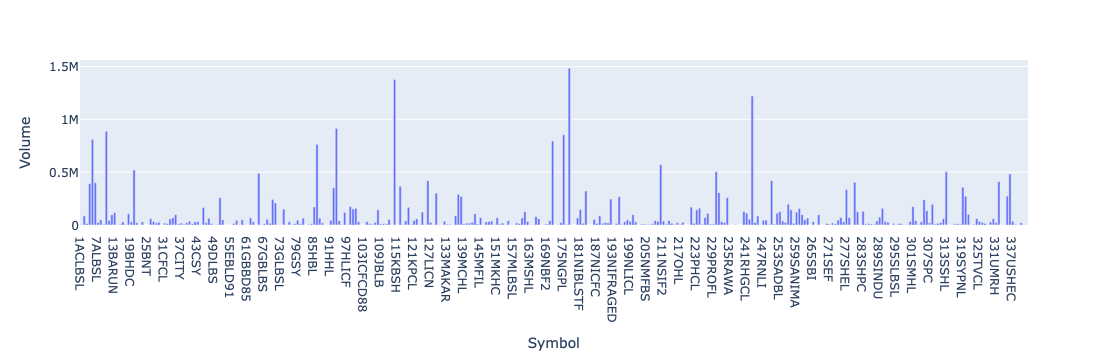

In [26]:
import plotly.express as px
df1 = df.sort_values(by = "Volume", ascending = False)[0:10]
fig = px.bar(df, x='Symbol', y='Volume')
fig.show()